라이브러리 불러오기

In [2]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

인물 사진 불러오기

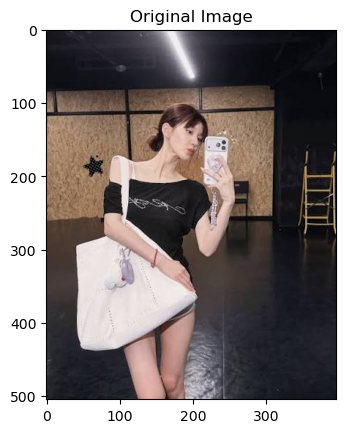

In [11]:
home_dir = os.getenv("HOME")

img_path = os.path.join(
    home_dir,
    "work/human_segmentation/images/human.jpg"
)

img_orig = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.show()

DeepLabV3 모델 불러오기

In [6]:
model = deeplabv3_resnet101(pretrained=True).eval()

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


이미지 전처리

In [7]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

input_tensor = transform(
    cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
).unsqueeze(0)

세크멘테이션 수행

In [8]:
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

원본 이미지 크기로 복원

In [9]:
output_predictions_resized = cv2.resize(
    output_predictions,
    (img_orig.shape[1], img_orig.shape[0]),
    interpolation=cv2.INTER_NEAREST
)

Segmentation 결과 확인

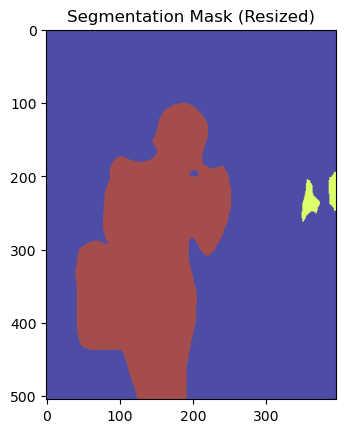

In [10]:
plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

인물 마스크 생성
person 클래스 번호 = 15

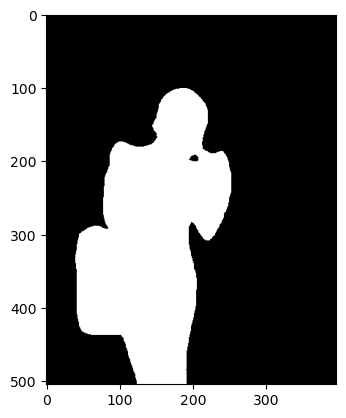

In [12]:
seg_map = (output_predictions_resized == 15)  
img_mask = seg_map.astype(np.uint8) * 255 
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  
plt.show()

마스크를 BGR로 변환

In [13]:
img_mask_color = cv2.cvtColor(
    img_mask,
    cv2.COLOR_GRAY2BGR
)

새로운 배경 이미지 불러오기

In [21]:
background_path = os.path.join(
    home_dir,
    "work/human_segmentation/images/background.jpg"
)

background_img = cv2.imread(background_path)

새 배경을 원본 인물 사진 크기로 변경

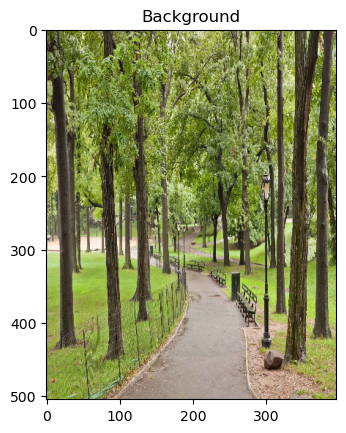

In [22]:
background_img = cv2.resize(
    background_img,
    (img_orig.shape[1], img_orig.shape[0])
)

plt.imshow(
    cv2.cvtColor(background_img, cv2.COLOR_BGR2RGB)
)
plt.title("Background")
plt.show()

인물과 새 배경 합성
인물 영역: 원본 이미지
배경 영역: 새로운 배경 이미지

In [23]:
img_chromakey = np.where(
    img_mask_color == 255,
    img_orig,
    background_img
)

최종 결과

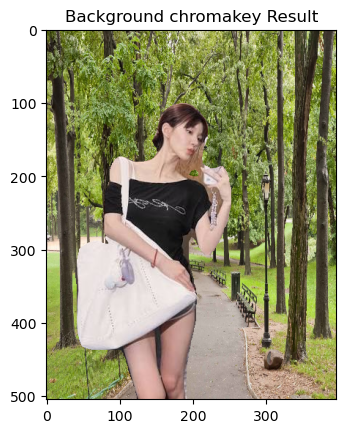

In [25]:
plt.imshow(
    cv2.cvtColor(img_chromakey, cv2.COLOR_BGR2RGB)
)
plt.title("Background chromakey Result")
plt.show()